# 04: Panel DiD and Fixed Effects

With many units and many time periods, DiD is usually written as
a panel regression with unit fixed effects and time fixed
effects.

The key variable is `did = treated_store * post`.

The two-way fixed-effects DiD model is

`sales_it = alpha_i + lambda_t + beta * did_it + error_it`,

where `alpha_i` is a store fixed effect and `lambda_t` is a
month fixed effect. The estimate of `beta` comes from treated
stores changing after rollout relative to control stores over
the same months.


In [1]:
from lite_setup import ensure_packages
await ensure_packages()

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import statsmodels.api as sm
import statsmodels.formula.api as smf

from checks import check_close, check_columns, check_same_estimate, check_sign
from did_utils import (
    did_2x2_table,
    manual_did,
    predicted_values_2x2,
    plot_group_trends,
    plot_did_counterfactual,
    make_event_dummies,
    extract_event_study_results,
    plot_event_study,
)
import patsy

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

DATA_DIR = Path("data")


Running outside JupyterLite; assuming packages are already installed.


In [2]:
df = pd.read_csv(DATA_DIR / "retail_rollout_panel.csv")
print(check_columns(df, ["store_id", "month", "treated_store", "post", "did", "sales", "foot_traffic", "ad_spend"]))
df.head()


Correct: all required columns are present.


,store_id,month,treated_store,post,did,sales,foot_traffic,ad_spend,region,store_size
0,ST001,1,1,0,0,144.41,890.4,57.43,North,small
1,ST001,2,1,0,0,147.98,889.8,66.85,North,small
2,ST001,3,1,0,0,146.85,952.9,60.71,North,small
3,ST001,4,1,0,0,156.35,954.0,62.04,North,small
4,ST001,5,1,0,0,149.40,951.4,73.73,North,small


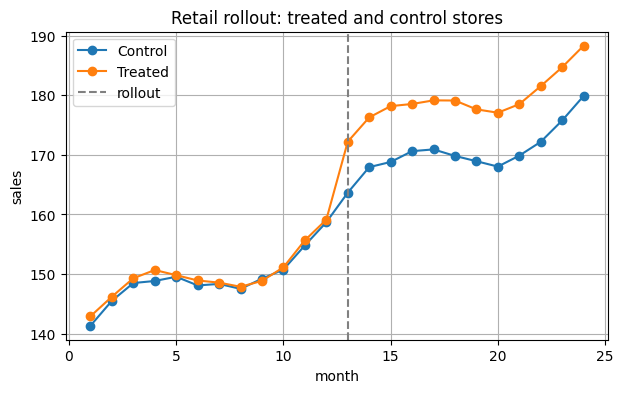

In [3]:
plot_group_trends(df, "sales", "month", "treated_store", title="Retail rollout: treated and control stores")
plt.axvline(13, color="gray", linestyle="--", label="rollout")
plt.legend()
plt.show()


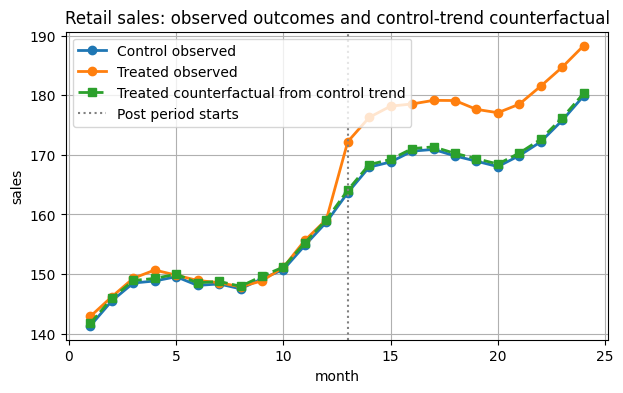

In [4]:
plot_did_counterfactual(
    df,
    "sales",
    "month",
    treated_col="treated_store",
    post_col="post",
    title="Retail sales: observed outcomes and control-trend counterfactual",
)
plt.show()


In [5]:
model_naive = smf.ols("sales ~ did", data=df).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["store_id"]},
)
model_unit_fe = smf.ols("sales ~ did + C(store_id)", data=df).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["store_id"]},
)
model_twfe = smf.ols("sales ~ did + C(store_id) + C(month)", data=df).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["store_id"]},
)
model_twfe_controls = smf.ols(
    "sales ~ did + foot_traffic + ad_spend + C(store_id) + C(month)",
    data=df,
).fit(cov_type="cluster", cov_kwds={"groups": df["store_id"]})

pd.DataFrame(
    {
        "estimate": [
            model_naive.params["did"],
            model_unit_fe.params["did"],
            model_twfe.params["did"],
            model_twfe_controls.params["did"],
        ],
        "std_error": [
            model_naive.bse["did"],
            model_unit_fe.bse["did"],
            model_twfe.bse["did"],
            model_twfe_controls.bse["did"],
        ],
    },
    index=["naive", "unit FE", "two-way FE", "two-way FE + controls"],
)


,estimate,std_error
naive,22.691611,1.746273
unit FE,29.344056,0.186189
two-way FE,8.074722,0.268274
two-way FE + controls,8.117461,0.189673


The estimates above use standard errors clustered by store.
Clustering matches the assignment level and allows observations
from the same store to be correlated over time.


## Event-study view

The two-way fixed-effects coefficient summarizes the post-period
effect with one number. The event-study version estimates a
separate treated-control difference for each relative month,
using month 12 (`relative_time = -1`) as the reference. We
restrict the regression to the displayed event window so the
omitted category is the reference month, not a mixture of the
reference month and other months outside the plot.


In [6]:
event_df = df.copy()
event_df["relative_time"] = event_df["month"] - 13
event_window = event_df.query("-6 <= relative_time <= 6").copy()
event_window, event_cols = make_event_dummies(
    event_window,
    rel_time_col="relative_time",
    treated_col="treated_store",
    omit=-1,
    window=(-6, 6),
)

event_formula = (
    "sales ~ "
    + " + ".join(event_cols)
    + " + foot_traffic + ad_spend + C(store_id) + C(month)"
)
event_model = smf.ols(event_formula, data=event_window).fit(
    cov_type="cluster",
    cov_kwds={"groups": event_window["store_id"]},
)
retail_event = extract_event_study_results(event_model)
retail_event


,relative_time,estimate,std_error
0,-6,-0.187190,0.787564
1,-5,0.523730,0.899928
2,-4,-0.582430,0.800849
3,-3,-0.168552,0.768735
4,-2,0.321721,0.778665
5,0,8.157721,0.904507
6,1,7.788397,0.708817
7,2,8.697261,0.881859
8,3,7.358130,0.758951
9,4,8.819224,0.839015


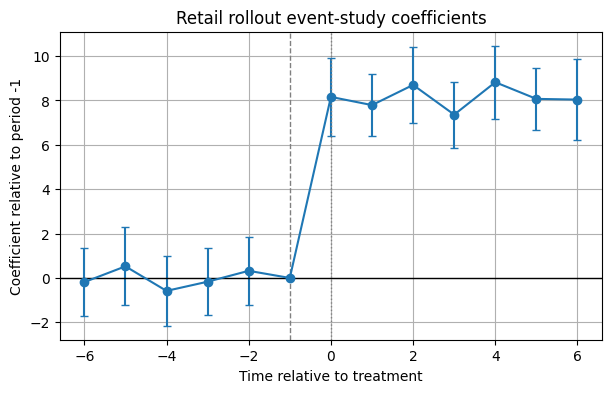

In [7]:
plot_event_study(retail_event, reference=-1, title="Retail rollout event-study coefficients")
plt.show()


## Why not include `treated_store` and `post` separately?

With `C(store_id)`, time-invariant store traits are absorbed,
including whether a store is in the treated group. With
`C(month)`, any shock common to all stores in a month is
absorbed, including the post-period indicator.

`did` can still be estimated because it varies by both unit and
time.


In [8]:
y, X = patsy.dmatrices(
    "sales ~ treated_store + post + did + C(store_id) + C(month)",
    data=df,
    return_type="dataframe",
)

print("Number of columns:", X.shape[1])
print("Matrix rank:", np.linalg.matrix_rank(X))
print("Columns exceed rank:", X.shape[1] > np.linalg.matrix_rank(X))


Number of columns: 86
Matrix rank: 84
Columns exceed rank: True


Takeaway: with unit and time fixed effects, the separate `Treat`
and `Post` variables are absorbed. The treatment effect is
estimated from the variable that turns on only for treated units
after treatment begins.
